Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_5.000/center_box/cavitation_initial.gsd
Loaded existing cavitation evolution:
/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_5.000/center_box/evolve_kT_0.800/nsteps_1000000/seed_1/cavitation_final.gsd
Evolution status: loaded_evolution
Source status: loaded_source


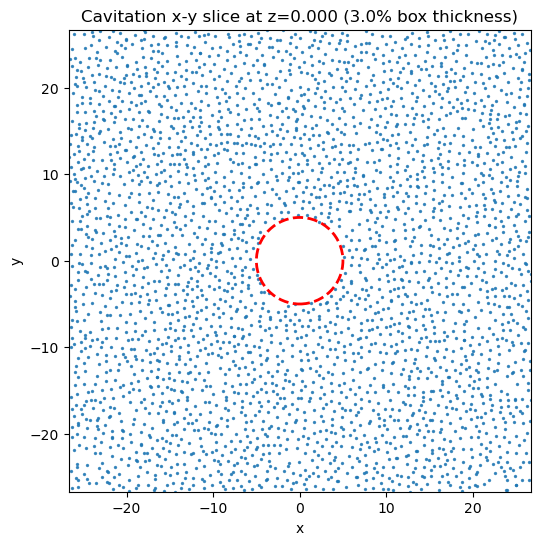

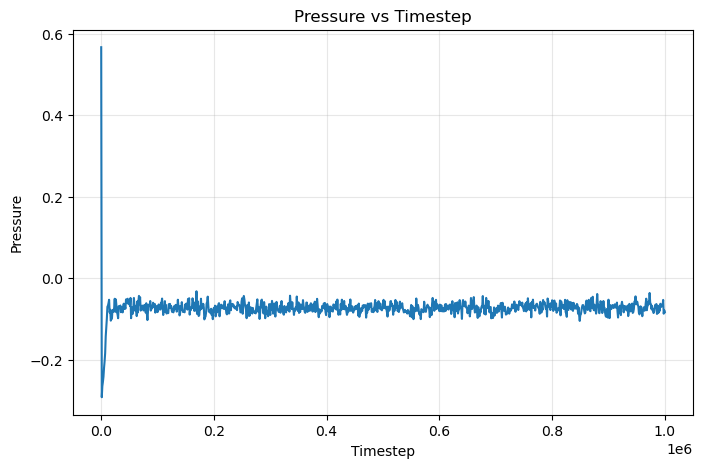

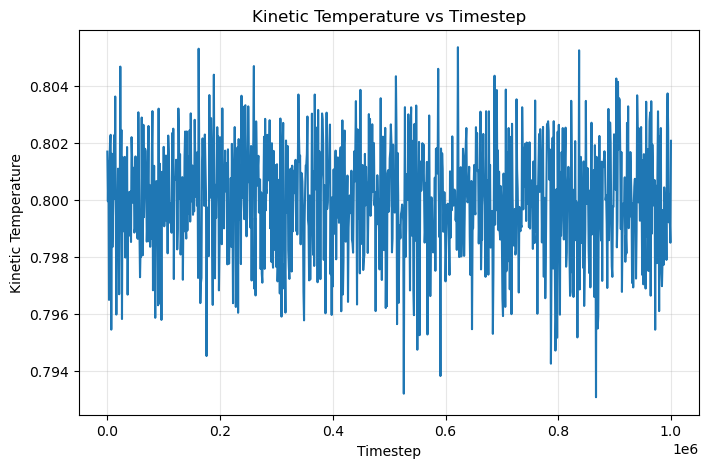

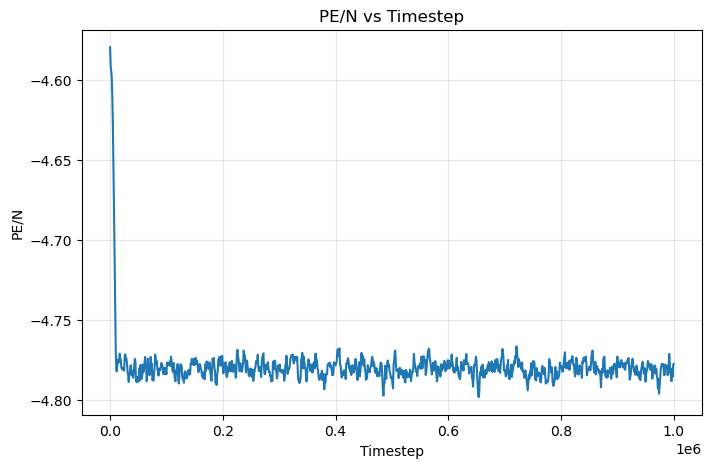

In [1]:
import importlib
from md_Helpers import visualization as vh
importlib.reload(vh)

import importlib
from md_Helpers import cavitation as cav
from md_Helpers import runs

importlib.reload(runs)
importlib.reload(cav)

evolution = cav.get_or_create_cavitation(
    n_fcc_cells=30,
    target_rho=0.71,
    kT=0.80,
    source_nsteps=1_000_000,
    radius=5,
    evolve_nsteps=1_000_000,

    create_source_if_missing=True,
    overwrite_source=False,
    overwrite=False,
)

print("Evolution status:", evolution["status"])
print("Source status:", evolution["initial_result"]["source_result"]["status"])

vh.plot_cavitation_xy_slice(
    evolution["initial_result"],
    fraction=0.03,
    point_size=2,
    alpha=0.8,
    show_bubble=True,
)

log_path = evolution["paths"]["log_path"]
log = runs.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_temperature")
vh.plot_log_quantity(log, "potential_energy")

In [14]:
from md_Helpers import visualization as vh

trajectory_path = evolution["paths"]["trajectory_path"]
center_z = evolution["initial_result"]["creation_info"].get("bubble_center_z", 0.0)

vh.animate_xy_slice_trajectory(
    trajectory_path,
    fraction=0.03,
    max_frames=100,
    interval=120,
)

In [2]:
from md_Helpers import classification as ps

log_path = evolution["paths"]["log_path"]

voxel_data, metadata_path = ps.read_phase_method_attrs(
    log_path,
    "voxel",
)

print("Metadata:", metadata_path)
print("Phase separated:", voxel_data["phase_separated"])
print("Low-density fraction:", voxel_data["low_density_fraction"])
print(voxel_data)

Metadata: metadata/classification/phase_separation/voxel
Phase separated: True
Low-density fraction: 0.037
{'density_threshold': 0.2, 'low_density_fraction': 0.037, 'max_voxel_density': 0.8480554993661439, 'mean_voxel_density': 0.707606990153289, 'method': 'voxel_low_density_fraction', 'min_voxel_density': 0.0, 'n_voxels': 1000, 'nbins': 10, 'phase_separated': True, 'std_voxel_density': 0.14476827138638024, 'updated_from_saved_gsd': True, 'voxel_fraction_threshold': 0.01, 'voxel_volume': 152.11268613483145}


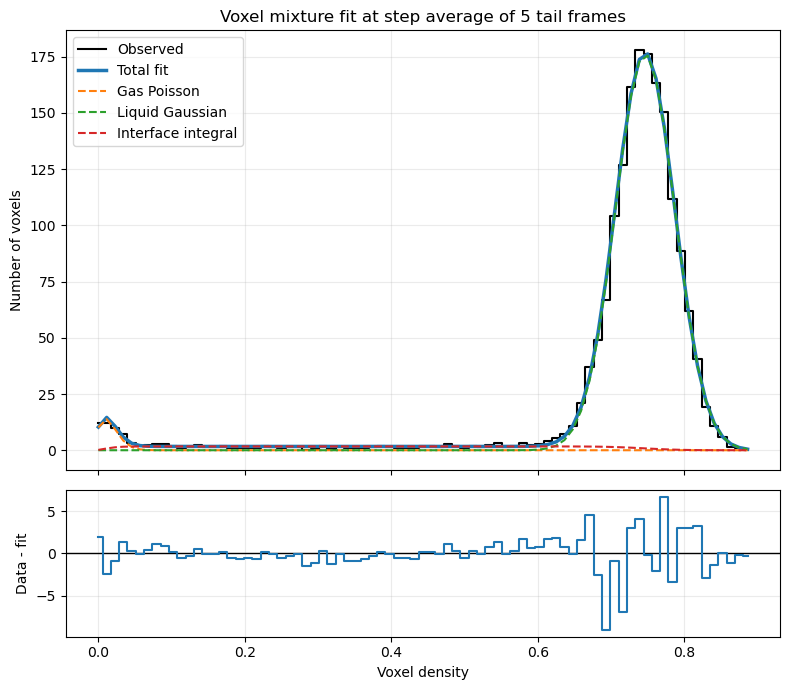

In [27]:
check = vh.fit_and_animate_final_bubble(
    evolution,
    nbins=12,
    nframes=5,
    skip=5,
    tail_fraction=0.1,
)

#check["animation"]

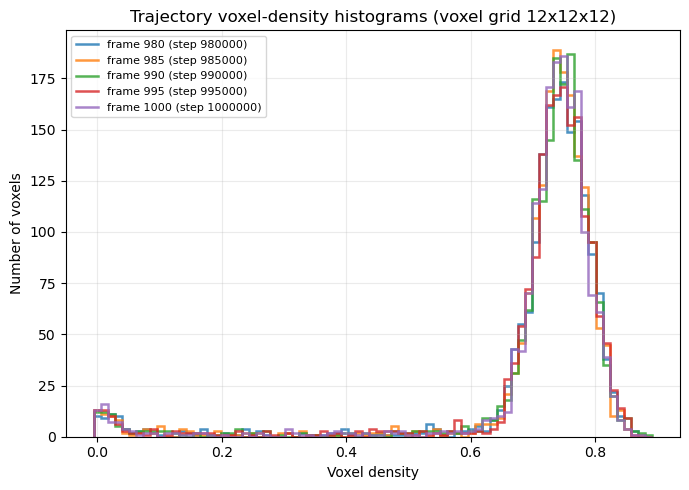

In [28]:
vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=check['fit']['voxel_nbins'],
    frame_indices=check['fit']['frame_indices'],
);

In [11]:
check.keys()

dict_keys(['fit', 'animation', 'fit_frame_indices', 'video_frame_indices', 'frame_indices', 'bubble_radius', 'bubble_volume', 'bubble_volume_fraction'])

In [12]:
check['bubble_radius']

12.535999404893078

In [16]:
check['fit']

{'success': True,
 'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
 'count_axis': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78]),
 'density_axis': array([0.        , 0.01136   , 0.02272   , 0.03408   , 0.04544   ,
        0.0568    , 0.06816   , 0.07951999, 0.09087999, 0.10223999,
        0.11359999, 0.12495999, 0.13631999, 0.14767999, 0.15903999,
        0.17039999, 0.18175999, 0.19311999, 0.20447999, 0.21583999,
        0.22719998, 0.23855998, 0.24991998, 0.26127998, 0.27263998,
        0.28399998, 0.29535998, 0.30671998, 0.31807998, 0.32943998,
        0.34079998, 0.35215998, 0.36351998, 0.37487998, 0.38623997,
        0.39759997, 0.40895997, 0.42031997, 0.4316